In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ecommerce_customer_data_large.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [4]:
df['Returns'] = df['Returns'].fillna(0)


In [5]:
df = df.drop_duplicates()


In [6]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

In [7]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[us]
 2   Product Category       250000 non-null  str           
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  str           
 7   Customer Age           250000 non-null  int64         
 8   Returns                250000 non-null  float64       
 9   Customer Name          250000 non-null  str           
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  str           
 12  Churn                  250000 non-null  int64         


In [9]:
df['Purchase Month'] = df['Purchase Date'].dt.month
df['Purchase Year'] = df['Purchase Date'].dt.year

In [10]:
df[['Purchase Date','Purchase Month','Purchase Year']].head()

,Purchase Date,Purchase Month,Purchase Year
0,2023-05-03 21:30:02,5,2023
1,2021-05-16 13:57:44,5,2021
2,2020-07-13 06:16:57,7,2020
3,2023-01-17 13:14:36,1,2023
4,2021-05-01 11:29:27,5,2021


In [11]:
category_sales = df.groupby('Product Category')['Total Purchase Amount'].sum()
category_sales

Product Category
Books          169345236
Clothing       170716122
Electronics    170146025
Home           171138916
Name: Total Purchase Amount, dtype: int64

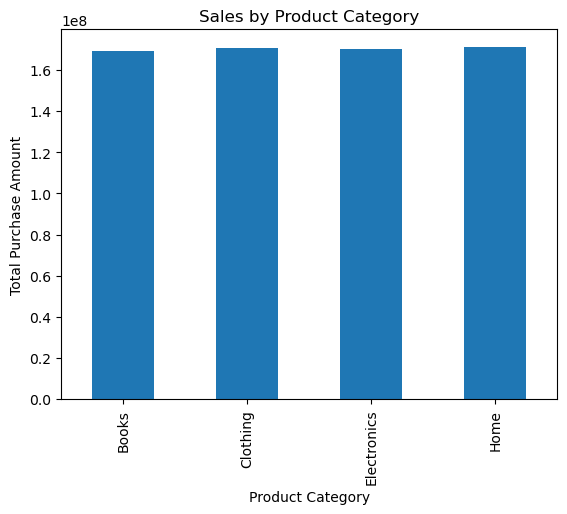

In [12]:
category_sales.plot(kind='bar')
plt.title('Sales by Product Category')
plt.ylabel('Total Purchase Amount')
plt.show()

In [13]:
df['Churn'].value_counts()

Churn
0    199870
1     50130
Name: count, dtype: int64

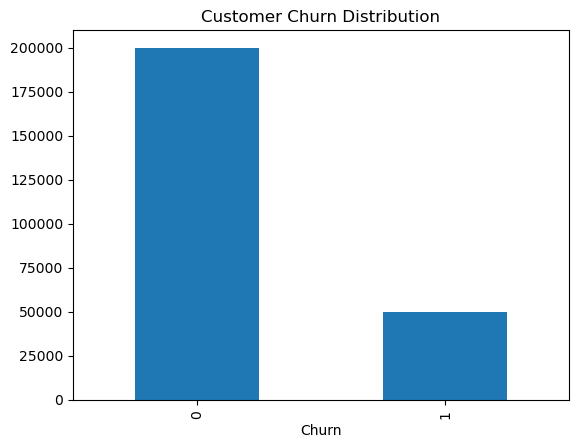

In [14]:
df['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.show()

In [15]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [16]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,289,3,6290
2,73,6,16481
3,223,4,9423
4,442,5,7826
5,425,5,9769


In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
1,289,3,6290,1
2,73,6,16481,2
3,223,4,9423,0
4,442,5,7826,1
5,425,5,9769,0


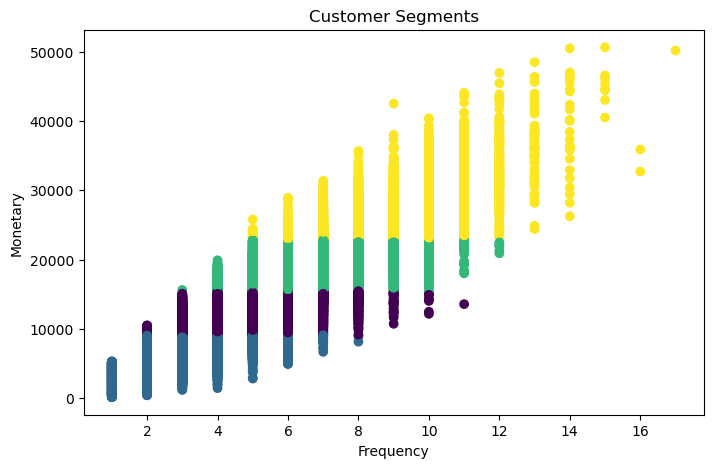

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments')
plt.show()

In [19]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,249.436914,4.675692,12251.138008
1,395.188809,2.789369,6006.613757
2,187.431018,6.438561,18623.329713
3,145.050528,8.737419,27098.361201


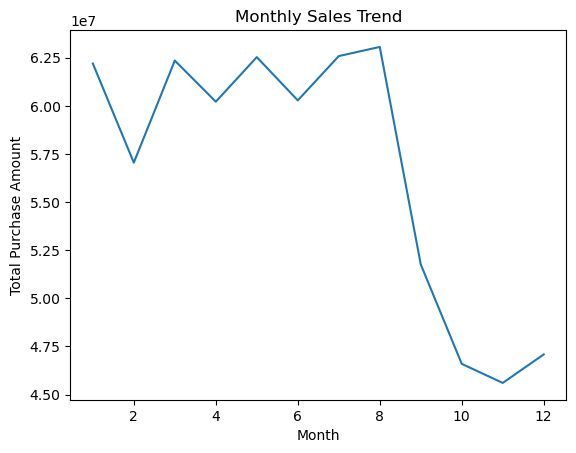

In [20]:
monthly_sales = df.groupby('Purchase Month')['Total Purchase Amount'].sum()

monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.show()

In [23]:
df.to_csv("cleaned_data.csv", index=False)

In [24]:
rfm.to_csv("rfm_segments.csv")